In [1]:
import sys
sys.path.append('../src/')

import atom
import matplotlib.pyplot as plt
import mrcfile
import pdbtools
import potential
import torch
from tqdm import tqdm
from plotting_tools import plot3d, plot_slices

%load_ext autoreload
%autoreload 2

## Plotting functions

## Download PDB file

In [55]:
folder = '../pdb-data/'
filename = pdbtools.fetch_pdb_file("6j6j", output=folder)
filename

Assemblies available: 1
6j6j: Fetching default Biological Assembly 1
File already exists: ../pdb-data/6j6j-assembly1.cif


'../pdb-data/6j6j-assembly1.cif'

## Extract atomic coordinates and recenter onto (0,0,0)

In [56]:
# extracts raw coordinates for each atom in (x,y,z) order from pdb file
atomic_numbers, coords = pdbtools.get_atoms_and_coordinates_from_pdb(filename)
atomic_numbers.shape, coords.shape

/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 3548.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 3564.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain C is discontinuous at line 3580.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain D is discontinuous at line 3596.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 3612.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/cryoem

(torch.Size([3624]), torch.Size([3624, 3]))

In [57]:
# elements in particle
print(set(atom.atom_symbol(atomic_numbers)))

{'O', 'C', 'N', 'S'}


In [58]:
coords.shape

torch.Size([3624, 3])

In [138]:
# recenters coordinates onto origin (0,0,0)
centered_coords = pdbtools.center_coordinates(coords)

## New grid sampling function

In [139]:
n = 256
dx = 0.25
x, y, z, X, Y, Z = potential.coordinate_grid_3d((n,n,n), (dx,dx,dx))

In [140]:
vol = potential.voxelize_atoms(centered_coords, grid_shape=(n,n,n), voxel_size=(dx, dx, dx))

In [141]:
softvol = potential.soft_voxelize_atoms(centered_coords, grid_shape=(n,n,n), voxel_size=(dx, dx, dx))

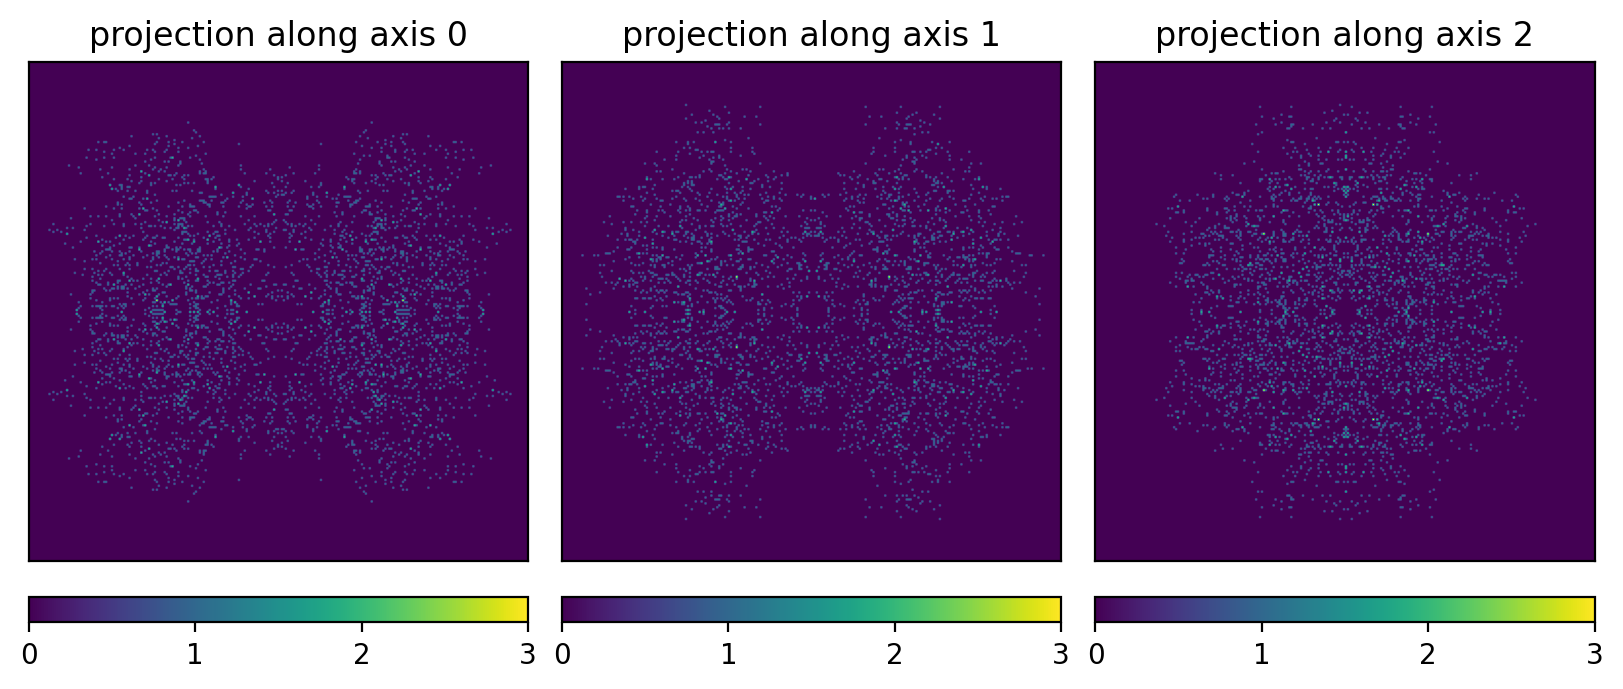

In [142]:
plot3d(vol)

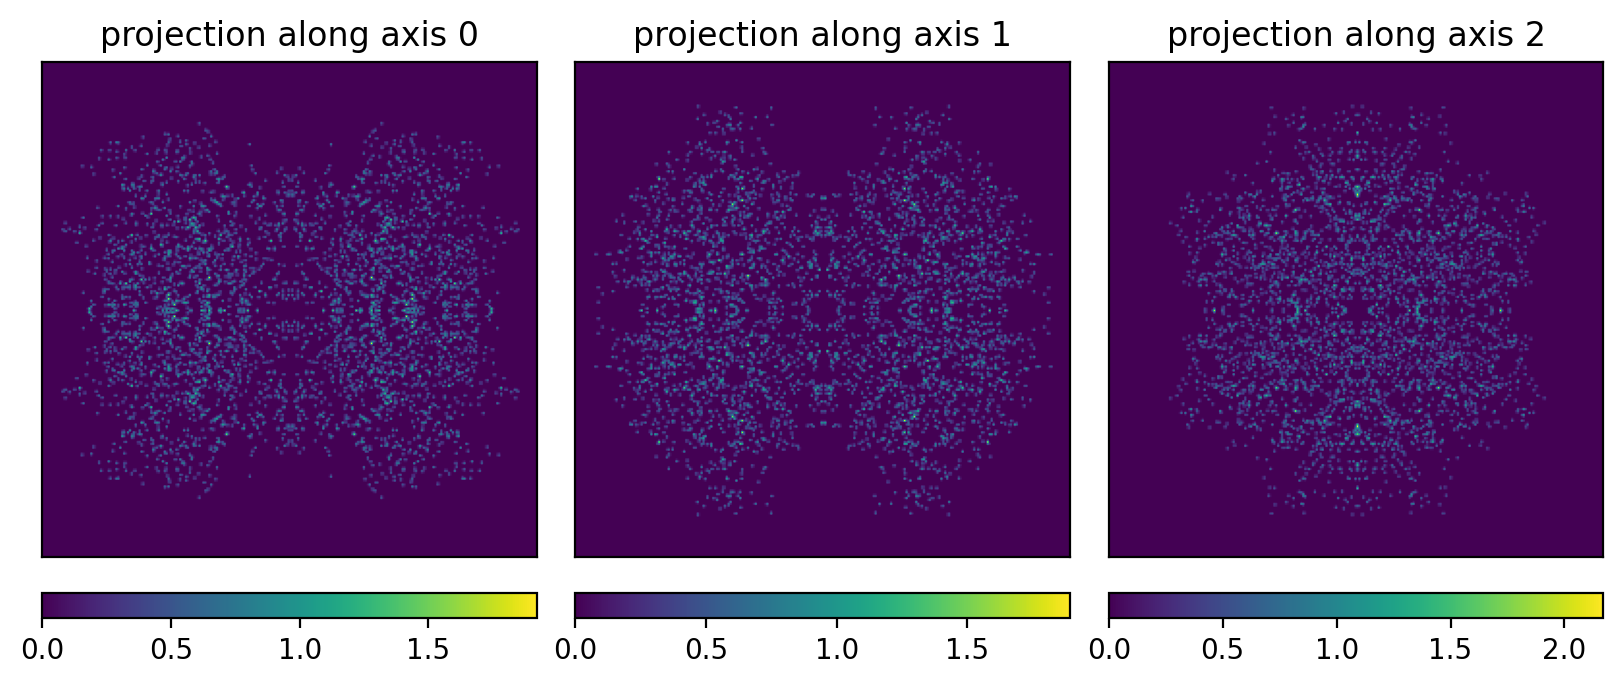

In [143]:
plot3d(softvol)

## Compute volumetric potential from PDB (2D Projection, Snap)

In [8]:
dx = 1
n = 256
super_sampling_factor = 4
vol_snapped_2d, occupancy = potential.build_potential_volume(
    atomic_numbers,
    centered_coords,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=11,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="snapped-2d",
)

46382it [00:06, 7524.49it/s]


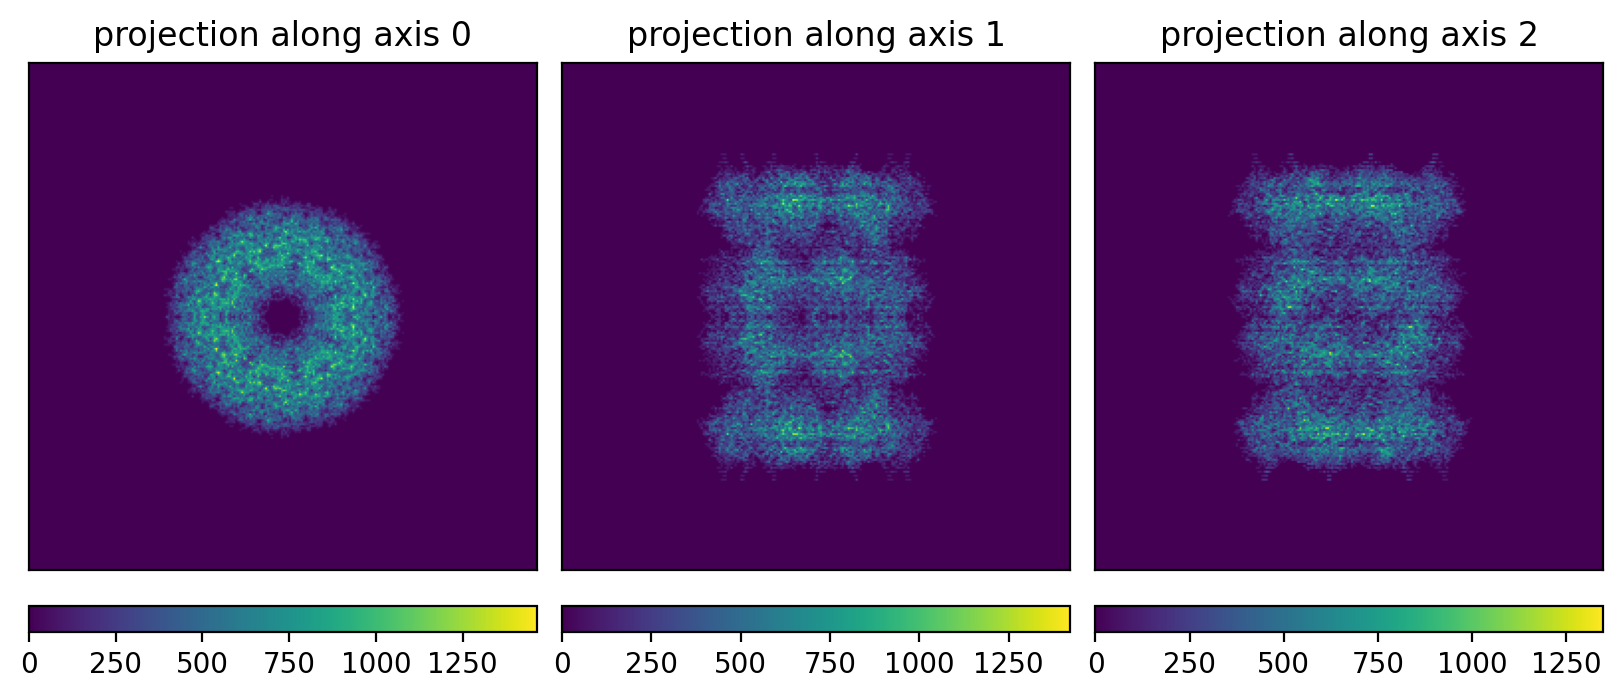

In [9]:
plot3d(vol_snapped_2d)

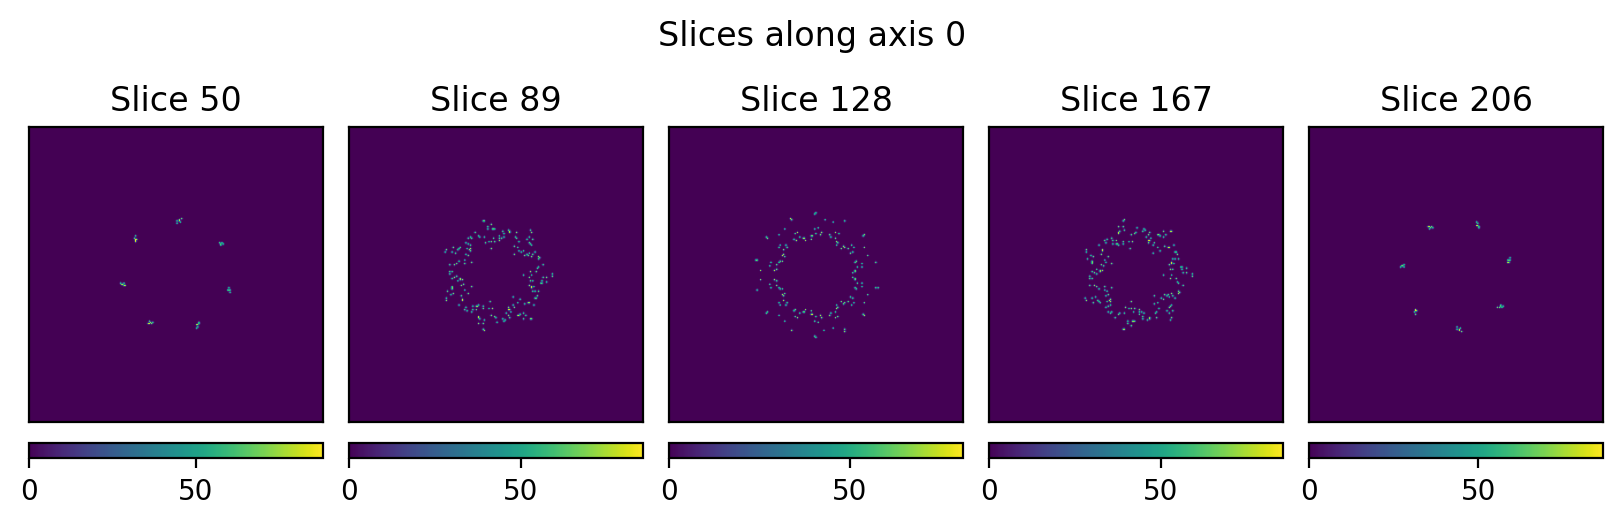

In [10]:
start_idx = 50
plot_slices(vol_snapped_2d, start_idx=start_idx, end_idx=n - start_idx)

## Compute volumetric potential from PDB (3D, Snap)

In [11]:
vol_snapped_3d, occupancy = potential.build_potential_volume(
    atomic_numbers,
    centered_coords,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=11,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="snapped-3d",
)

46382it [00:06, 7148.60it/s]


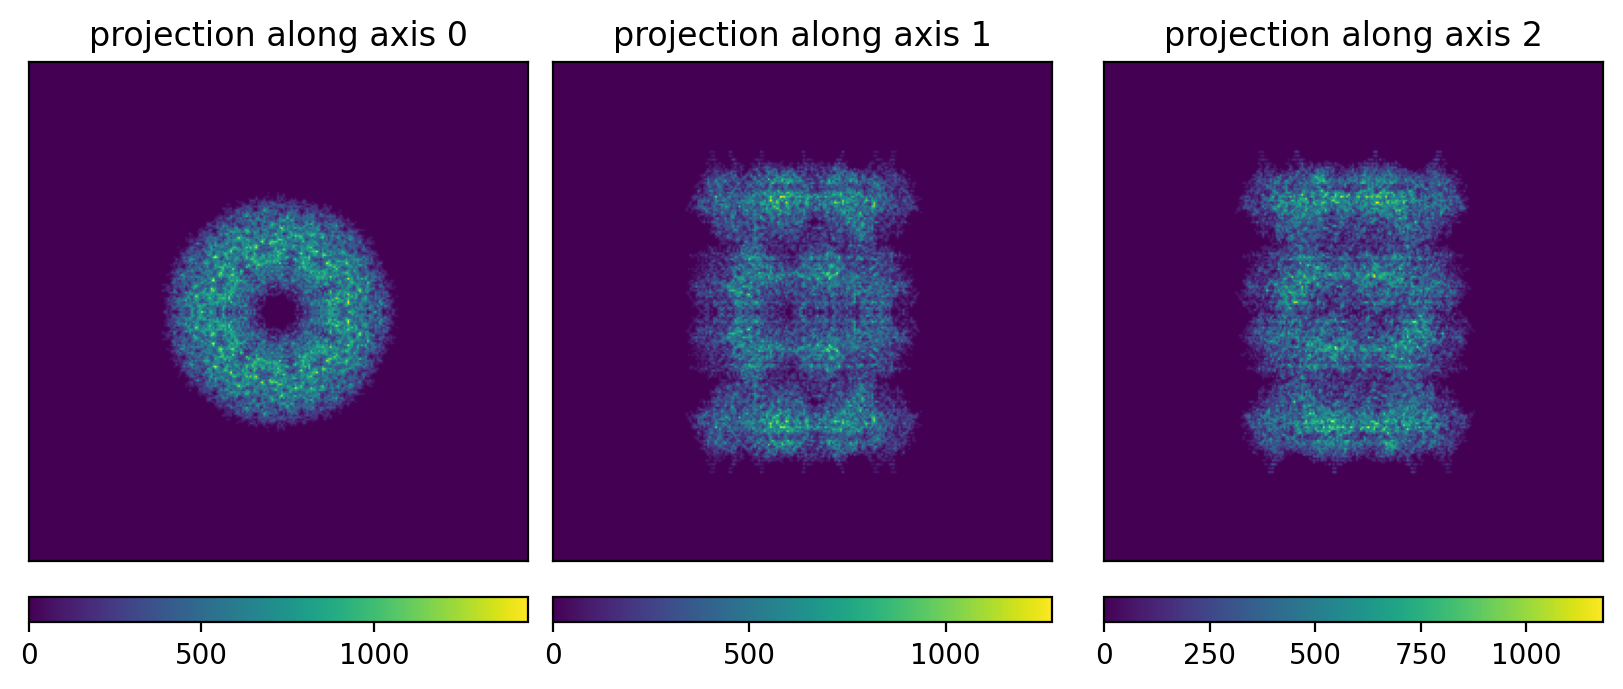

In [12]:
plot3d(vol_snapped_3d)

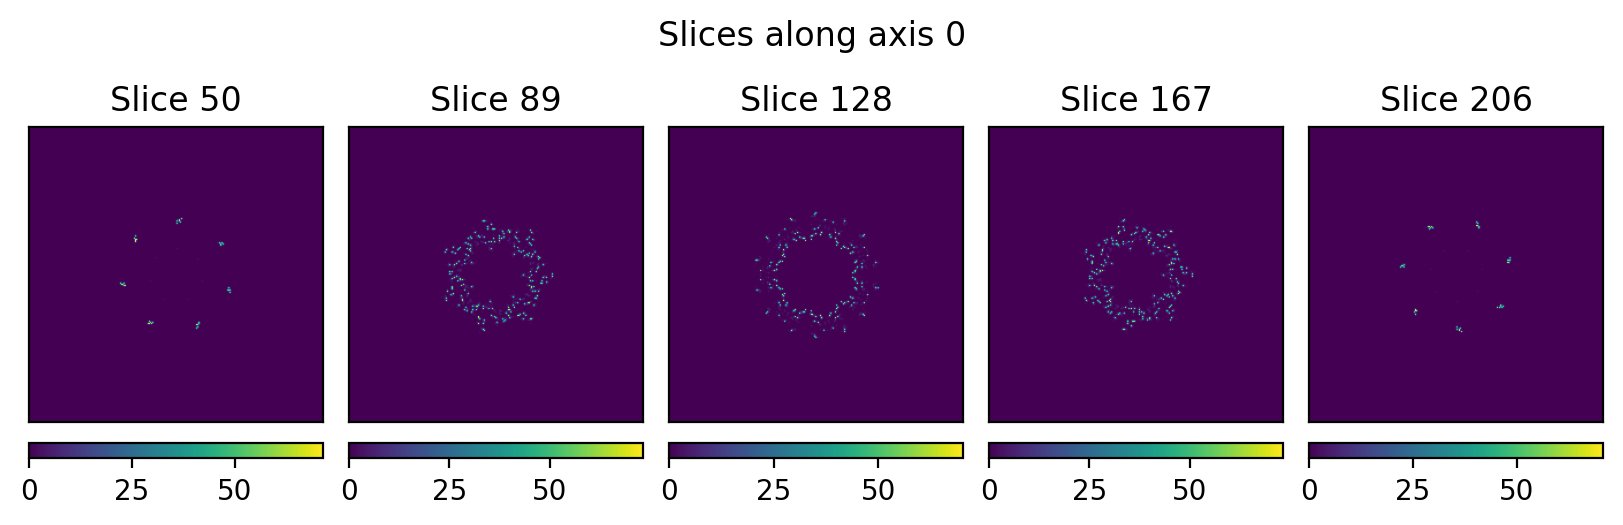

In [13]:
start_idx = 50
plot_slices(vol_snapped_3d, start_idx=start_idx, end_idx=n - start_idx)

## Compute volumetric potential from PDB (2D Projection, snap-in-z only)

In [14]:
vol_2d, occupancy = potential.build_potential_volume(
    atomic_numbers,
    centered_coords,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=11,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="2d",
)

46382it [03:14, 238.72it/s]


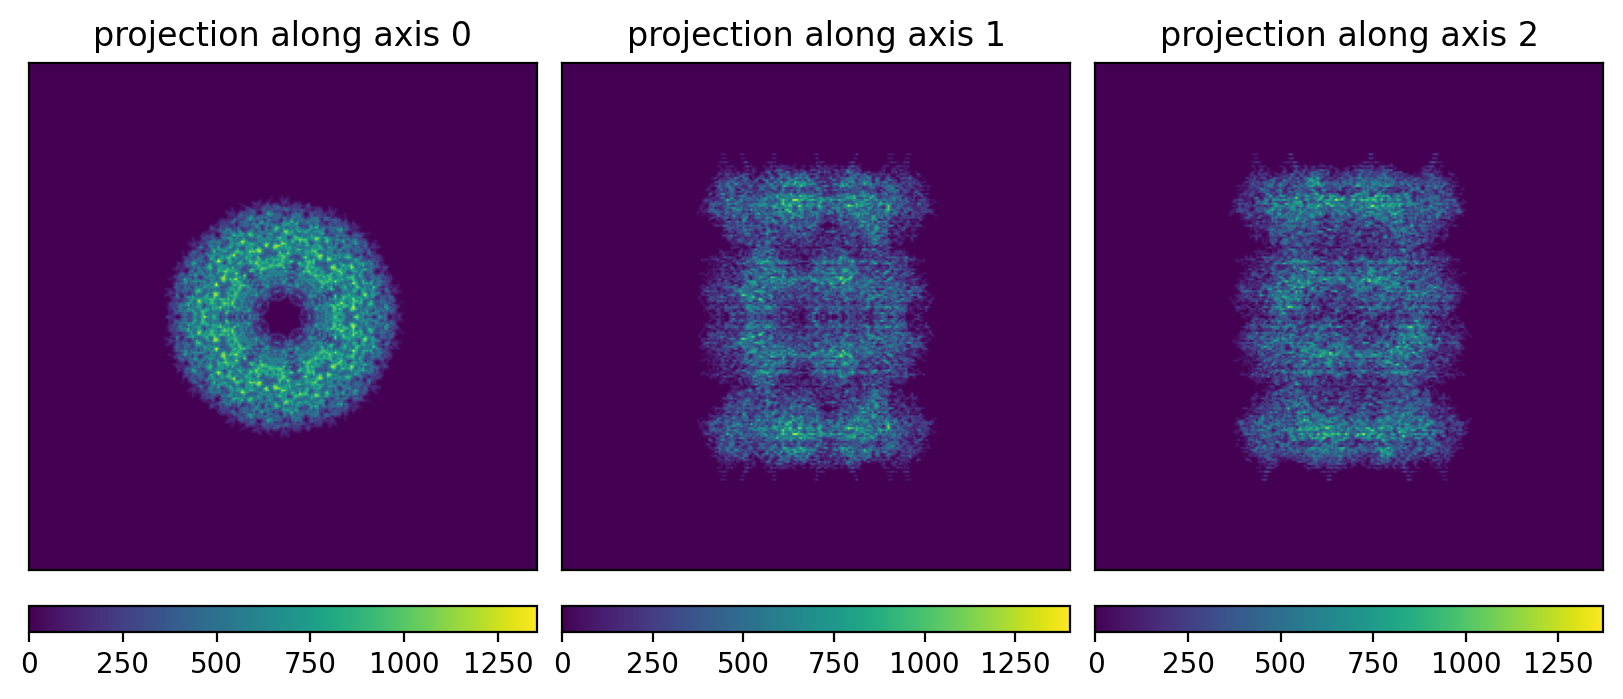

In [15]:
plot3d(vol_2d)

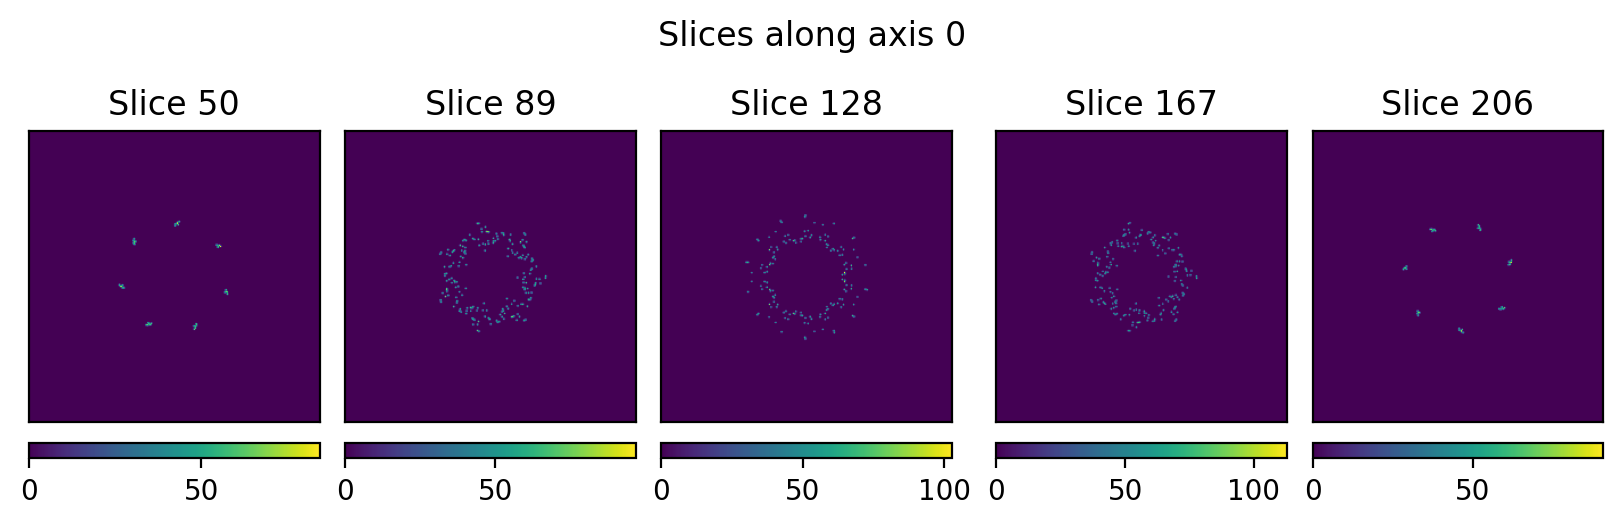

In [16]:
start_idx = 50
plot_slices(vol_2d, start_idx=start_idx, end_idx=n - start_idx)

## Compute volumetric potential from PDB (3D, no-snap)

In [17]:
vol_3d, occupancy = potential.build_potential_volume(
    atomic_numbers,
    centered_coords,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=11,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="3d",
)

46382it [03:26, 225.01it/s]


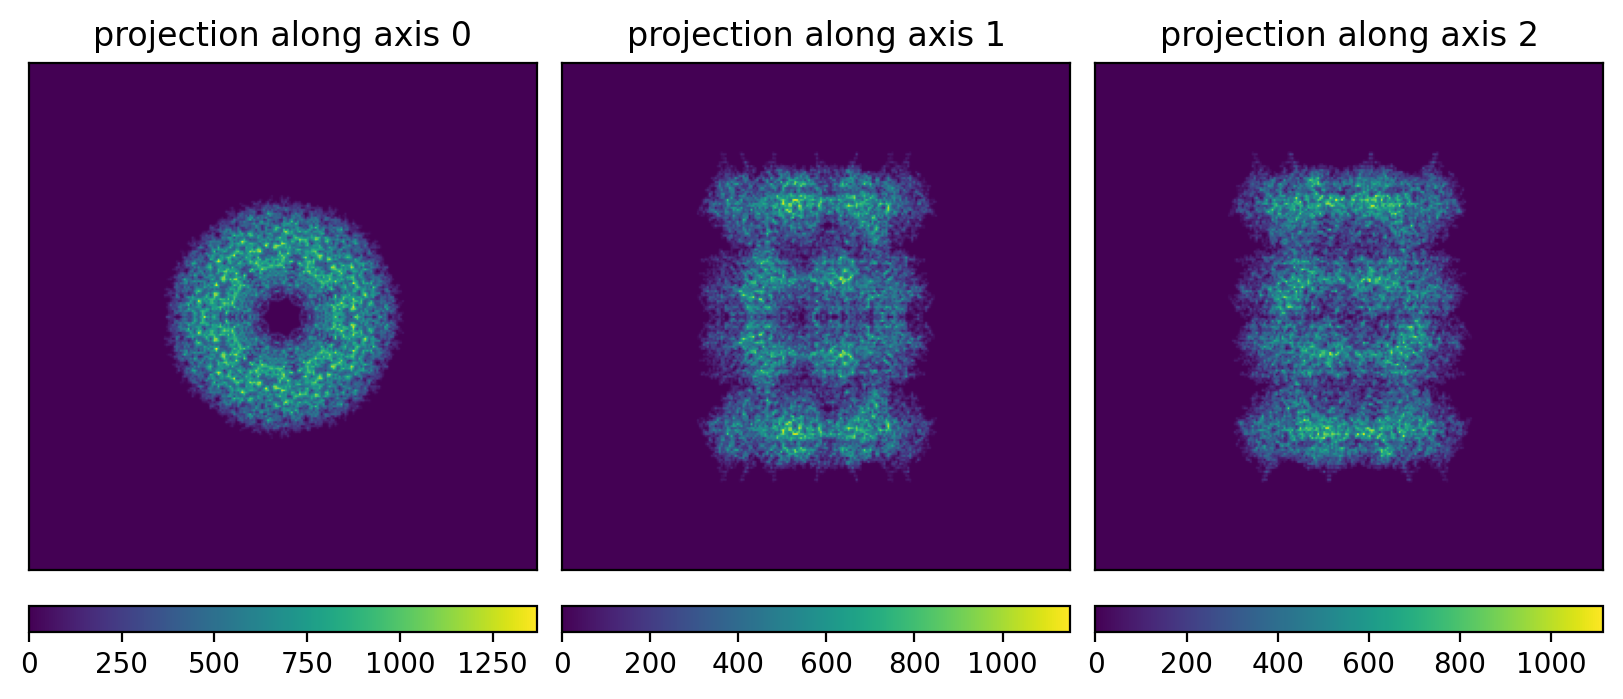

In [18]:
plot3d(vol_3d)

## Compare error between snap and no-snap

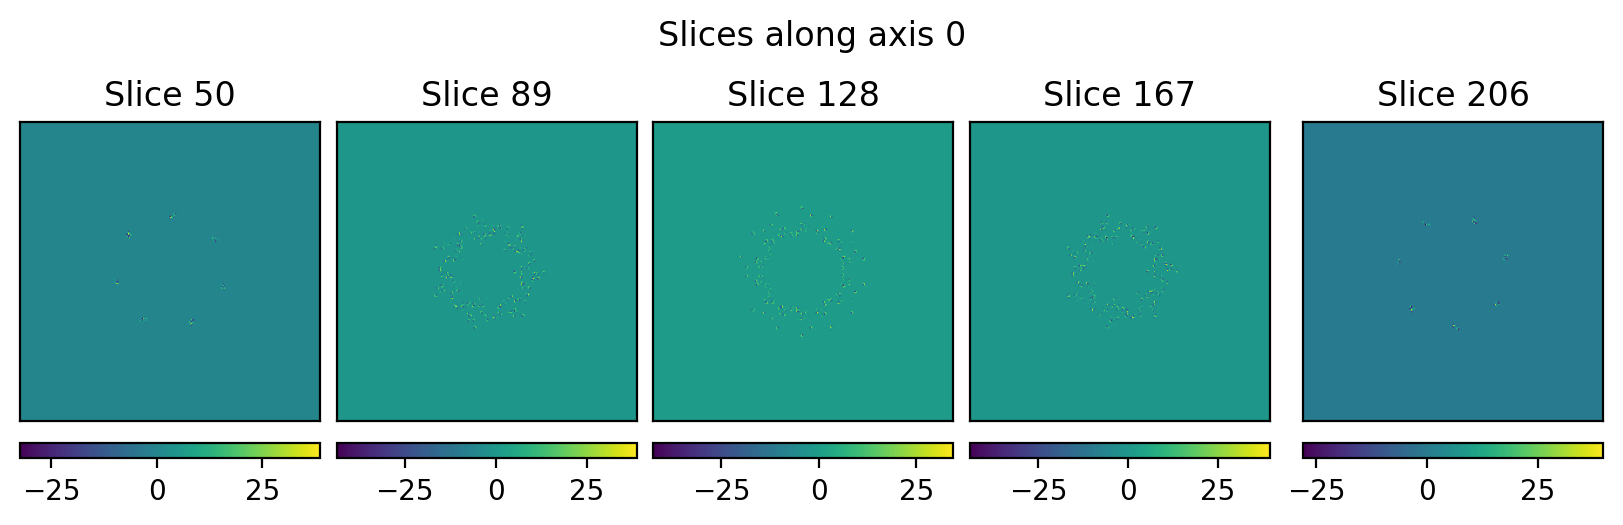

In [19]:
start_idx = 50
plot_slices(vol_2d - vol_snapped_2d, start_idx=start_idx, end_idx=n - start_idx)

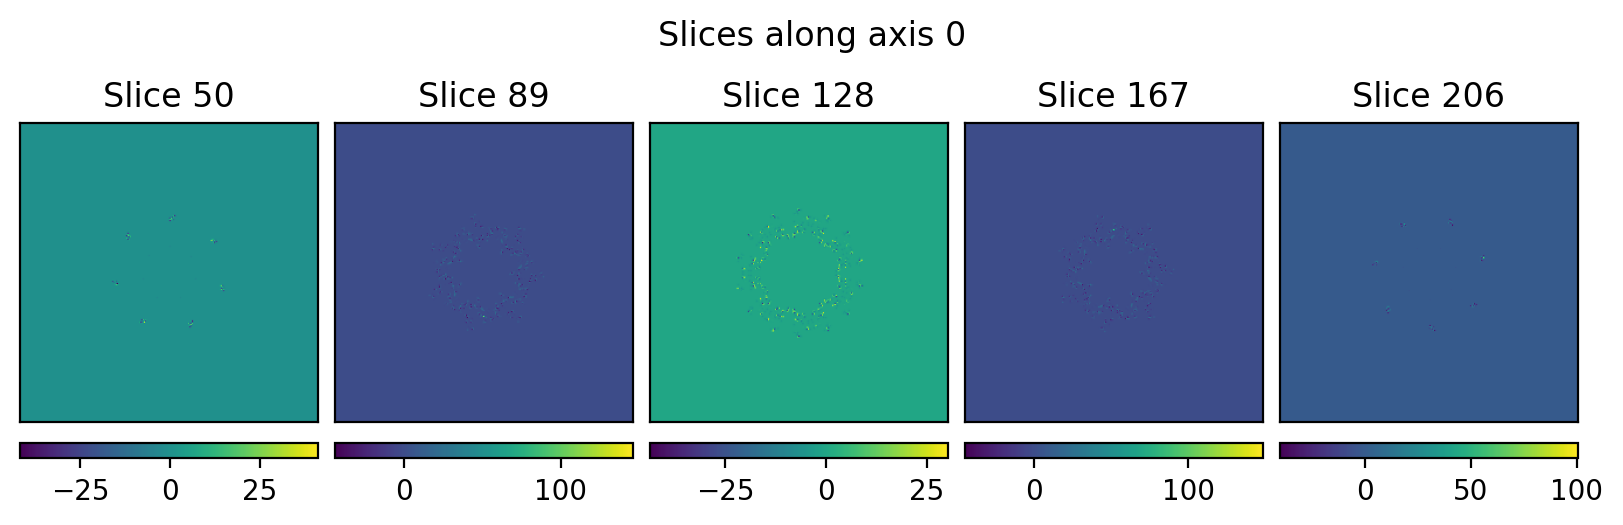

In [20]:
start_idx = 50
plot_slices(vol_3d - vol_snapped_3d, start_idx=start_idx, end_idx=n - start_idx)